In [1]:
pip install mne 

Note: you may need to restart the kernel to use updated packages.


In [106]:
import mne
import numpy as np
import matplotlib
matplotlib.use('Agg')         
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
import warnings
import os
import zipfile
from matplotlib.lines import Line2D

warnings.filterwarnings('ignore')

In [3]:
!pip install python-picard

In [4]:
!pip install pyprep

In [5]:
listener_path = "/kaggle/input/datasets/aielitist29/neurodyad2026/Neurodyad_Test/Listener.edf"
speaker_path = "/kaggle/input/datasets/aielitist29/neurodyad2026/Neurodyad_Test/Speaker.edf"

In [6]:
speaker_data = mne.io.read_raw_edf(speaker_path , preload =True)
listener_data = mne.io.read_raw_edf(listener_path, preload = True)

Extracting EDF parameters from /kaggle/input/datasets/aielitist29/neurodyad2026/Neurodyad_Test/Speaker.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 75749  =      0.000 ...   302.996 secs...
Extracting EDF parameters from /kaggle/input/datasets/aielitist29/neurodyad2026/Neurodyad_Test/Listener.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 75749  =      0.000 ...   302.996 secs...


In [7]:
for label, raw in [('SPEAKER', speaker_data), ('LISTENER', listener_data)]:
    print(f"\n{'='*50}")
    print(f"  {label}")
    print(f"{'='*50}")
    print(f"  Channels   : {raw.info['nchan']}")
    print(f"  Sfreq      : {raw.info['sfreq']} Hz")
    print(f"  Duration   : {raw.times[-1]:.5f} s  ({raw.times[-1]/60:.5f} min)")
    print(f"  Channel names (first 5): {raw.ch_names[:65]}")


  SPEAKER
  Channels   : 65
  Sfreq      : 250.0 Hz
  Duration   : 302.99600 s  (5.04993 min)
  Channel names (first 5): ['EEG 1', 'EEG 2', 'EEG 3', 'EEG 4', 'EEG 5', 'EEG 6', 'EEG 7', 'EEG 8', 'EEG 9', 'EEG 10', 'EEG 11', 'EEG 12', 'EEG 13', 'EEG 14', 'EEG 15', 'EEG 16', 'EEG 17', 'EEG 18', 'EEG 19', 'EEG 20', 'EEG 21', 'EEG 22', 'EEG 23', 'EEG 24', 'EEG 25', 'EEG 26', 'EEG 27', 'EEG 28', 'EEG 29', 'EEG 30', 'EEG 31', 'EEG 32', 'EEG 33', 'EEG 34', 'EEG 35', 'EEG 36', 'EEG 37', 'EEG 38', 'EEG 39', 'EEG 40', 'EEG 41', 'EEG 42', 'EEG 43', 'EEG 44', 'EEG 45', 'EEG 46', 'EEG 47', 'EEG 48', 'EEG 49', 'EEG 50', 'EEG 51', 'EEG 52', 'EEG 53', 'EEG 54', 'EEG 55', 'EEG 56', 'EEG 57', 'EEG 58', 'EEG 59', 'EEG 60', 'EEG 61', 'EEG 62', 'EEG 63', 'EEG 64', 'EEG VREF']

  LISTENER
  Channels   : 65
  Sfreq      : 250.0 Hz
  Duration   : 302.99600 s  (5.04993 min)
  Channel names (first 5): ['EEG 1', 'EEG 2', 'EEG 3', 'EEG 4', 'EEG 5', 'EEG 6', 'EEG 7', 'EEG 8', 'EEG 9', 'EEG 10', 'EEG 11', 'EEG 12',

### EEG VREF is the baseline 0 for all the other EEG channels, an EEG channel measures the difference in points not the actual one so EEG i = EEG i - EEG VREF 
### EEG VREF is placed somehwere neutral like vertex of head, mastoids or earlobes 

In [8]:
def extract_din1_times(raw, label=''):
    """
    Returns a sorted list of onset times (in seconds) for all DIN1 annotations.
    Handles both 'DIN1' and 'DIN 1' variants.
    """
    annots = raw.annotations
    din1_times = [
        annot['onset']
        for annot in annots
        if 'DIN1' in annot['description'].replace(' ', '') or
           annot['description'].strip() == 'DIN1'
    ]
    din1_times = sorted(din1_times)
    print(f"\n{label} — DIN1 markers found: {len(din1_times)}")
    for i, t in enumerate(din1_times):
        print(f"   Marker {i+1}: {t:.4f} s  (sample ~{int(t * raw.info['sfreq'])})")
    return din1_times


# Also print ALL unique annotation types so nothing is missed
def print_all_annotations(raw, label=''):
    unique = set(a['description'] for a in raw.annotations)
    print(f"\n{label} — All annotation types: {unique}")

print_all_annotations(speaker_data,  'SPEAKER')
print_all_annotations(listener_data, 'LISTENER')

sp_din1_times = extract_din1_times(speaker_data,  'SPEAKER')
ls_din1_times = extract_din1_times(listener_data, 'LISTENER')


SPEAKER — All annotation types: {np.str_('VBeg'), np.str_('DIN1'), np.str_('VEnd')}

LISTENER — All annotation types: {np.str_('DIN1')}

SPEAKER — DIN1 markers found: 3
   Marker 1: 0.7880 s  (sample ~197)
   Marker 2: 148.5610 s  (sample ~37140)
   Marker 3: 148.8350 s  (sample ~37208)

LISTENER — DIN1 markers found: 3
   Marker 1: 1.0050 s  (sample ~251)
   Marker 2: 148.7780 s  (sample ~37194)
   Marker 3: 149.0520 s  (sample ~37263)


In [24]:
PLOT_CHANS = ['EEG 1', 'EEG 10', 'EEG 20', 'EEG 30', 'EEG 64' , 'EEG 65']   
PLOT_SECS  = 30

fig, axes = plt.subplots(len(PLOT_CHANS), 2, figsize=(18, 10),
                         sharex=True, sharey=False)
fig.suptitle('Sanity Check — First 30 s of Raw EEG', fontsize=14, fontweight='bold')

for ax_col, (raw, label) in enumerate([(speaker_data, 'Speaker'),
                                        (listener_data, 'Listener')]):
    sfreq   = raw.info['sfreq']
    n_samps = int(PLOT_SECS * sfreq)

    for ax_row, ch in enumerate(PLOT_CHANS):
        ax = axes[ax_row][ax_col]
        if ch in raw.ch_names:
            idx   = raw.ch_names.index(ch)
            times = raw.times[:n_samps]
            data  = raw.get_data(picks=[idx])[0, :n_samps] * 1e6   # → µV
            ax.plot(times, data, linewidth=0.6, color='#2E86AB')
            ax.set_ylabel(ch, fontsize=8)
        else:
            ax.text(0.5, 0.5, f'{ch} not found', ha='center', va='center',
                    transform=ax.transAxes, color='red')
        if ax_row == 0:
            ax.set_title(label, fontsize=11)

        # Draw vertical lines for the markers
        din_times = sp_din1_times if ax_col == 0 else ls_din1_times
        for t in din_times:
            if t <= PLOT_SECS:
                ax.axvline(t, color='red', linewidth=1.2, linestyle='--', alpha=0.8)

axes[-1][0].set_xlabel('Time (s)')
axes[-1][1].set_xlabel('Time (s)')
plt.tight_layout()

plt.show()
print('\nRed dashed lines = DIN1 markers')


Red dashed lines = DIN1 markers


In [10]:
for label, times in [('SPEAKER', sp_din1_times), ('LISTENER', ls_din1_times)]:
    if len(times) < 3:
        raise ValueError(
            f"{label}: Expected ≥ 3 DIN1 markers, found {len(times)}. "
            "Check annotation parsing above."
        )
print('✓ Both files contain ≥ 3 DIN1 markers.')

✓ Both files contain ≥ 3 DIN1 markers.


In [11]:
# ── 2.2  Crop Segments ───────────────────────────────────────────────────────
def crop_segment(raw, tmin, tmax=None, label=''):
    """
    Returns a cropped copy of `raw`. If tmax is None, crops to end of file.
    """
    t_end = tmax if tmax is not None else raw.times[-1]
    seg = raw.copy().crop(tmin=tmin, tmax=t_end)
    dur = seg.times[-1]
    print(f"  {label:30s}  tmin={tmin:.2f}s  tmax={t_end:.2f}s  → duration={dur:.2f}s")
    return seg


print("\n── Speaker Segments ──")
sp_positive = crop_segment(speaker_data,
                            tmin=sp_din1_times[0],
                            tmax=sp_din1_times[1],
                            label='Speaker — Positive')

sp_negative = crop_segment(speaker_data,
                            tmin=sp_din1_times[2],
                            tmax=None,
                            label='Speaker — Negative')

print("\n── Listener Segments ──")
ls_positive = crop_segment(listener_data,
                            tmin=ls_din1_times[0],
                            tmax=ls_din1_times[1],
                            label='Listener — Positive')

ls_negative = crop_segment(listener_data,
                            tmin=ls_din1_times[2],
                            tmax=None,
                            label='Listener — Negative')


── Speaker Segments ──
  Speaker — Positive              tmin=0.79s  tmax=148.56s  → duration=147.77s
  Speaker — Negative              tmin=148.84s  tmax=303.00s  → duration=154.16s

── Listener Segments ──
  Listener — Positive             tmin=1.00s  tmax=148.78s  → duration=147.77s
  Listener — Negative             tmin=149.05s  tmax=303.00s  → duration=153.94s


## Mutually align the data just like the main project

In [12]:
def mutually_align_cuts(raw1, raw2, label=''):
    """
    Align two EEG recordings by mutually identifying and removing cut segments.
    (Official NeuroDyads Project implementation)
    """
    sfreq = raw1.info['sfreq']
    data1 = raw1.get_data().copy()
    data2 = raw2.get_data().copy()

    # 1. Pad the shorter file with zeros
    max_len = max(data1.shape[1], data2.shape[1])
    if data1.shape[1] < max_len:
        pad = np.zeros((data1.shape[0], max_len - data1.shape[1]))
        data1 = np.concatenate([data1, pad], axis=1)
    if data2.shape[1] < max_len:
        pad = np.zeros((data2.shape[0], max_len - data2.shape[1]))
        data2 = np.concatenate([data2, pad], axis=1)

    # 2. Insert zeros based on annotations (e.g., if researchers marked "bad" sections)
    def insert_zeros(data, annotations):
        if annotations is not None:
            for onset, duration in zip(annotations.onset, annotations.duration):
                start = int(onset * sfreq)
                stop = int((onset + duration) * sfreq)
                data[:, start:stop] = 0
        return data

    data1 = insert_zeros(data1, raw1.annotations)
    data2 = insert_zeros(data2, raw2.annotations)

    # 3. Identify zero regions (where either file has missing/bad data)
    zero_mask = np.all(data1 == 0, axis=0) | np.all(data2 == 0, axis=0)

    # 4. Find cut segments
    zero_diff = np.diff(np.concatenate(([0], zero_mask.astype(int), [0])))
    start_idxs = np.where(zero_diff == 1)[0]
    end_idxs = np.where(zero_diff == -1)[0]

    # 5. Create annotations for the cuts
    new_annotations = []
    for start, end in zip(start_idxs, end_idxs):
        onset = start / sfreq
        duration = (end - start) / sfreq
        new_annotations.append((onset, duration))

    # 6. Define keep segments
    keep_segments = []
    current = 0
    for start, end in zip(start_idxs, end_idxs):
        if start > current:
            keep_segments.append((current, start))
        current = end
    if current < max_len:
        keep_segments.append((current, max_len))

    # 7. Rebuild both files using only the "keep" segments
    def extract(data):
        return np.concatenate([data[:, s:e] for s, e in keep_segments], axis=1)

    new_data1 = extract(data1)
    new_data2 = extract(data2)

    # 8. Create new Raw objects (suppressing the verbose creation output)
    raw1_clean = mne.io.RawArray(new_data1, raw1.info.copy(), verbose=False)
    raw2_clean = mne.io.RawArray(new_data2, raw2.info.copy(), verbose=False)

    # 9. Add shared annotations back in
    if new_annotations:
        annots = mne.Annotations(
            onset=[a[0] for a in new_annotations],
            duration=[a[1] for a in new_annotations],
            description=['cut'] * len(new_annotations)
        )
        raw1_clean.set_annotations(annots)
        raw2_clean.set_annotations(annots)

    # Print a summary of the alignment
    original_dur = raw1.times[-1]
    new_dur = raw1_clean.times[-1]
    print(f"  {label}: Mutually aligned. Duration went from {original_dur:.2f}s -> {new_dur:.2f}s")
    
    return raw1_clean, raw2_clean

# ── Execute the Alignment ──

print("\n── Applying Mutual Alignment ──")
# 1. Align the Positive Segments
sp_positive, ls_positive = mutually_align_cuts(sp_positive, ls_positive, label="Positive Affect")

# 2. Align the Negative Segments
sp_negative, ls_negative = mutually_align_cuts(sp_negative, ls_negative, label="Negative Affect")


── Applying Mutual Alignment ──
  Positive Affect: Mutually aligned. Duration went from 147.77s -> 147.77s
  Negative Affect: Mutually aligned. Duration went from 154.16s -> 149.59s


In [14]:
sp_concat = mne.concatenate_raws([sp_positive.copy(), sp_negative.copy()])
ls_concat = mne.concatenate_raws([ls_positive.copy(), ls_negative.copy()])

print(f"Speaker  concatenated duration : {sp_concat.times[-1]:.2f} s")
print(f"Listener concatenated duration : {ls_concat.times[-1]:.2f} s")
print("\n✓ Segments cropped and concatenated successfully.")

Speaker  concatenated duration : 297.36 s
Listener concatenated duration : 297.36 s

✓ Segments cropped and concatenated successfully.


In [15]:
# ── 3.1  Drop VREF ───────────────────────────────────────────────────────────
VREF_NAME = 'EEG VREF'   # change if the channel is named differently in your files

def drop_vref(raw, label=''):
    if VREF_NAME in raw.ch_names:
        raw.drop_channels([VREF_NAME])
        print(f"  {label}: Dropped '{VREF_NAME}'.  Remaining channels: {raw.info['nchan']}")

for seg in [sp_concat, ls_concat, sp_positive, sp_negative, ls_positive, ls_negative]:
    drop_vref(seg)

print("\nChannel count after VREF removal:",
      sp_concat.info['nchan'], '(expect 64)')

  : Dropped 'EEG VREF'.  Remaining channels: 64
  : Dropped 'EEG VREF'.  Remaining channels: 64
  : Dropped 'EEG VREF'.  Remaining channels: 64
  : Dropped 'EEG VREF'.  Remaining channels: 64
  : Dropped 'EEG VREF'.  Remaining channels: 64
  : Dropped 'EEG VREF'.  Remaining channels: 64

Channel count after VREF removal: 64 (expect 64)


In [16]:
rename_dict = {f'EEG {i}': f'E{i}' for i in range(1, 65)}

segments = [sp_concat, ls_concat, sp_positive, sp_negative, ls_positive, ls_negative]

for seg in segments:
    if 'EEG 1' in seg.ch_names:
        mne.rename_channels(seg.info, rename_dict, allow_duplicates=False)

In [17]:
print(sp_concat.info)

<Info | 8 non-empty values
 bads: []
 ch_names: E1, E2, E3, E4, E5, E6, E7, E8, E9, E10, E11, E12, E13, E14, ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 125.0 Hz
 meas_date: 2023-09-12 03:57:01 UTC
 nchan: 64
 projs: []
 sfreq: 250.0 Hz
 subject_info: <subject_info | his_id: NT#10-speak, sex: 0, last_name: X>
>


In [19]:
def assign_montage(raw, label=''):
    montage = mne.channels.make_standard_montage('GSN-HydroCel-64_1.0')
    try:
        raw.set_montage(montage, on_missing='warn')
        print(f"  {label}: Montage 'GSN-HydroCel-64_1.0' assigned.")
    except Exception as e:
        print(f"  {label}: Montage assignment failed — {e}")
        print("  Try 'GSN-HydroCel-64_1.0', 'EGI_256', or a custom .sfp file.")

for seg, lbl in [(sp_concat,   'sp_concat'),
                  (ls_concat,   'ls_concat'),
                  (sp_positive, 'sp_positive'),
                  (sp_negative, 'sp_negative'),
                  (ls_positive, 'ls_positive'),
                  (ls_negative, 'ls_negative')]:
    assign_montage(seg, lbl)

  sp_concat: Montage 'GSN-HydroCel-64_1.0' assigned.
  ls_concat: Montage 'GSN-HydroCel-64_1.0' assigned.
  sp_positive: Montage 'GSN-HydroCel-64_1.0' assigned.
  sp_negative: Montage 'GSN-HydroCel-64_1.0' assigned.
  ls_positive: Montage 'GSN-HydroCel-64_1.0' assigned.
  ls_negative: Montage 'GSN-HydroCel-64_1.0' assigned.


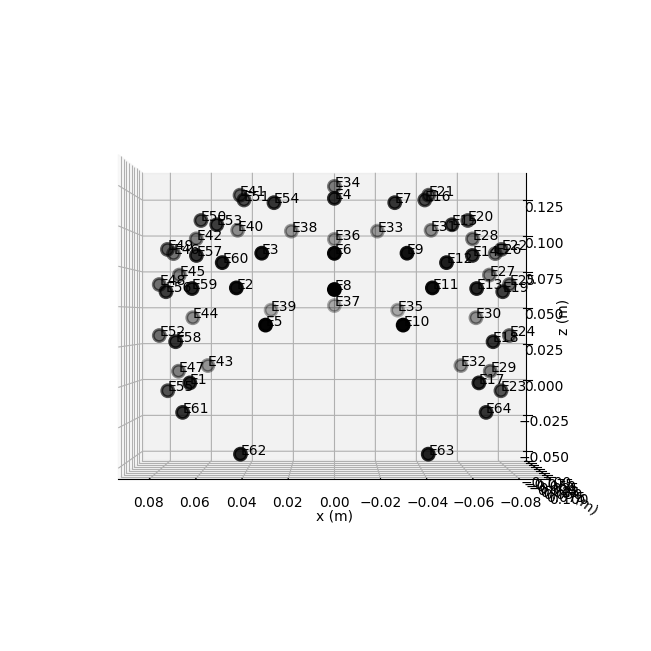

In [21]:
sp_concat.plot_sensors(kind='3d', show_names = True)

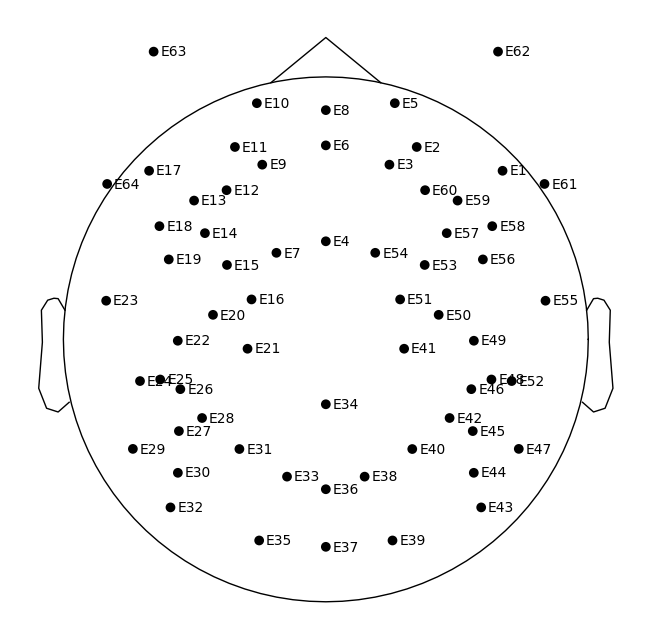

In [23]:
sp_concat.plot_sensors(show_names = True)

## We will now create a brain_tree to divide all the electrodes according to which part of the brain it was sampling electrical signals from

In [25]:
eeg_brain_tree = {
    "Brain": {
        "Left_Hemisphere": {
            "Prefrontal": ["E10"],
            "Frontal": ["E11", "E12", "E13", "E14", "E15", "E17", "E18", "E19"],
            "Central": ["E20", "E21", "E22"],
            "Temporal": ["E23", "E24", "E25", "E26", "E27", "E28", "E29", "E30", "E64"],
            "Parietal": ["E31", "E33"],
            "Occipital": ["E32", "E35"]
        },
        "Right_Hemisphere": {
            "Prefrontal": ["E5"],
            "Frontal": ["E1", "E2", "E3", "E6", "E53", "E54", "E56", "E57", "E58", "E59", "E60"],
            "Central": ["E41", "E49", "E50"],
            "Temporal": ["E40", "E42", "E44", "E45", "E46", "E47", "E48", "E52", "E55", "E61"],
            "Parietal": ["E36", "E38"],
            "Occipital": ["E39", "E43"]
        },
        "Midline": {
            "Prefrontal": ["E8"],
            "Frontal": ["E4", "E7", "E9"],
            "Central": ["E16", "E34", "E51"], # E34 acts as the Cz (Vertex) equivalent
            "Parietal": [], # In this specific 64-ch net, parietal midline is sparse
            "Occipital": ["E37"]
        },
        "Off_Scalp_EOG": {
            "Left_Eye": ["E63"],
            "Right_Eye": ["E62"]
        }
    }
}

In [26]:
def get_channels_by_region(tree=eeg_brain_tree, hemisphere=None, lobe=None):
    """
    Extracts a list of channels based on hemisphere, lobe, or both.
    Leave a parameter as None to grab everything in that category.
    """
    selected_channels = []
    
    # Define which hemispheres to search
    hemispheres_to_search = [hemisphere] if hemisphere else ["Left_Hemisphere", "Right_Hemisphere", "Midline"]
    
    for hemi in hemispheres_to_search:
        if hemi in tree["Brain"]:
            for current_lobe, channels in tree["Brain"][hemi].items():
                # If a specific lobe is requested, only grab that one. Otherwise, grab all.
                if lobe is None or current_lobe == lobe:
                    selected_channels.extend(channels)
                    
    return selected_channels

In [27]:
left_brain = get_channels_by_region(eeg_brain_tree , hemisphere = 'Left_Hemisphere')
print(left_brain)

['E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E17', 'E18', 'E19', 'E20', 'E21', 'E22', 'E23', 'E24', 'E25', 'E26', 'E27', 'E28', 'E29', 'E30', 'E64', 'E31', 'E33', 'E32', 'E35']


## Since we have dropped out the EEG VREF, the absolute signal doesnot have any reference, so we have to create one, so by our time window that is 1/250s that 4 mili second, we will take avergae of all values across 64 channels and subtract it from all, so now for every time sample our data is mean centered 
## This is because of the theory, that CAR assumes that if you have enough electrodes covering the whole head, the sum of all electrical activity should be 0, so by subtracting mean for every time sample it removes the noise which hit all electrodes at the same time making the sum not equal to 0 

## To properly filter the data we need infinite amount of it(for sinc function to act as brickfall), here we donot so instead of abruptly chopping off which will lead to Gibbs phenomena(When signal transformed to frequency domain from time it will create "ripples"(frequencies we need may shutoff and one we donot may come in) around the cutoff) , so filtering window comes in, the fir_window(finite impulse response) instead of chopping it off smoothens the end towards 0.
## Here we used Hamming windown at 1Hz High pas filtering.
## Hamming function -> w(n) = 0.54 - 0.46cos(2*pi*n/N-1) where N is the filter length and n is each point in filter, so at the end becomes 0.08, meaning it will not touch 0 but will become 8percent of what it was at cutoff point, this offset was kept to cutoff the highest ripple in frequency domain, here it suppress the noise from 1 to 0.5 by -6db which means almost half in amplitude and below that by -53 db means multiplying amplitude by 1/100,000 

In [29]:
sp_filt = sp_concat.copy().filter(l_freq=1.0, h_freq=None,
                                    fir_window='hamming', verbose=True)
ls_filt = ls_concat.copy().filter(l_freq=1.0, h_freq=None,
                                    fir_window='hamming', verbose=True)

print("1 Hz high-pass copies created for ICA fitting.")

Filtering raw data in 2 contiguous segments
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 825 samples (3.300 s)

Filtering raw data in 2 contiguous segments
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 825 samples (3.300 s)

1 Hz high-pass copies created for ICA fitting.


## Automatic bad channel detection 

In [30]:

from pyprep.find_noisy_channels import NoisyChannels

def detect_and_interpolate_bads(raw_filt, raw_main, label=''):
    print(f"\n── {label}: Pyprep Bad Channel Detection ──")
    
    # 1. Run pyprep on the 1Hz high-pass filtered data
    nc = NoisyChannels(raw_filt, random_state=1337)
    nc.find_all_bads()  # <--- Removed the print_summary argument here!
    
    # 2. Gather all the broken channels pyprep flagged
    all_bads = list(set(
        nc.bad_by_nan +
        nc.bad_by_flat +
        nc.bad_by_deviation +
        nc.bad_by_hf_noise +
        nc.bad_by_correlation +
        nc.bad_by_ransac
    ))
    
    print(f"  Found {len(all_bads)} bad hardware channels: {all_bads}")
    
    # 3. Mark them as bad in BOTH the filtered and main datasets
    raw_filt.info['bads'] = all_bads
    raw_main.info['bads'] = all_bads
    
    # 4. Interpolate to reconstruct the missing data
    if all_bads:
        raw_filt.interpolate_bads(reset_bads=True)
        raw_main.interpolate_bads(reset_bads=True)
        print(f"  Successfully reconstructed missing channels on both datasets.")
    else:
        print(f"  Hardware looks pristine! No interpolation needed.")
        
    return raw_filt, raw_main

# Apply the function to Speaker data
sp_filt, sp_concat = detect_and_interpolate_bads(sp_filt, sp_concat, "Speaker")

# Apply the function to Listener data
ls_filt, ls_concat = detect_and_interpolate_bads(ls_filt, ls_concat, "Listener")


── Speaker: Pyprep Bad Channel Detection ──
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 825 samples (3.300 s)

Executing RANSAC
This may take a while, so be patient...


  0%|          |  : 0/59 [00:00<?,       ?it/s]


RANSAC done!
  Found 21 bad hardware channels: [np.str_('E47'), 'E5', 'E32', 'E55', np.str_('E64'), 'E22', 'E62', 'E52', 'E58', 'E7', 'E27', 'E48', 'E21', 'E50', 'E63', 'E40', 'E17', 'E39', 'E23', 'E43', 'E29']
Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 94.3 mm
Computing interpolation matrix from 43 sensor positions
Interpolating 21 sensors
Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 94.3 mm
Computing interpolation matrix from 43 sensor positions
Interpolating 21 sensors
  Successfully reconstructed missing channels on both datasets.

── Listener: Pyprep Bad Channel Detection ──
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB 

  0%|          |  : 0/59 [00:00<?,       ?it/s]


RANSAC done!
  Found 4 bad hardware channels: [np.str_('E63'), 'E10', 'E41', 'E55']
Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 94.3 mm
Computing interpolation matrix from 60 sensor positions
Interpolating 4 sensors
Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 94.3 mm
Computing interpolation matrix from 60 sensor positions
Interpolating 4 sensors
  Successfully reconstructed missing channels on both datasets.


In [31]:
for seg, lbl in [(sp_concat, 'sp_concat'), (ls_concat, 'ls_concat'), 
                 (sp_filt, 'sp_filt'), (ls_filt, 'ls_filt')]:
    seg.set_eeg_reference('average', projection=False)
    print(f"  {lbl}: Re-referenced to clean average.")

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
  sp_concat: Re-referenced to clean average.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
  ls_concat: Re-referenced to clean average.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
  sp_filt: Re-referenced to clean average.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
  ls_filt: Re-referenced to clean average.


## ICA - Because of the distance between the skull and brain and their different resistivities, electroencephalographic (EEG) data collected fromany point on the human scalp includes activity generated withina large brain area. 
## (1) ICA training is insensitive to different random seeds.
## (2) ICA may be used to segregate obvious artifactual EEG components(line and muscle noise, eye movements) from other sources. 
## (3) ICAis capable of isolating overlapping EEG phenomena, including alpha and theta bursts and spatially-separable ERP components, toseparate ICA channels.
## (4) N onstationarities in EEG and behavioral state can be tracked using ICA via changes in the amount ofresidual correlation between ICA-filtered output channels. 

## 15 Chosen as Dyadic Neural Dynamics used same but they used Extended Infomax ICA here i used Extended Picard as it uses L-BFGS method(which include calculation of hessian) it will reach more accurate minima than extended infomax using infinite time.

## By keeping the N_Components as 0.95 it will first run PCA to keep exactly enough components to explain 95 percent of the variance, then it will run ICA on whatever the number is 

In [53]:
N_COMPONENTS = 0.95 
RANDOM_STATE = 42

ica_speaker = mne.preprocessing.ICA(
    n_components=N_COMPONENTS,
    method='picard',         
    max_iter='auto',
    random_state=RANDOM_STATE,fit_params=dict(extended=True)
)

ica_listener = mne.preprocessing.ICA(
    n_components=N_COMPONENTS,
    method='picard',
    max_iter='auto',
    random_state=RANDOM_STATE,fit_params=dict(extended=True)
)

print('Fitting ICA on Speaker data (1 Hz HP copy)...')
ica_speaker.fit(sp_filt)
print('Fitting ICA on Listener data (1 Hz HP copy)...')
ica_listener.fit(ls_filt)
print('\n✓ ICA fitting complete.')

Fitting ICA on Speaker data (1 Hz HP copy)...
Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by explained variance: 10 components
Fitting ICA took 5.3s.
Fitting ICA on Listener data (1 Hz HP copy)...
Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by explained variance: 16 components
Fitting ICA took 11.5s.

✓ ICA fitting complete.


── Speaker ICA Components ──


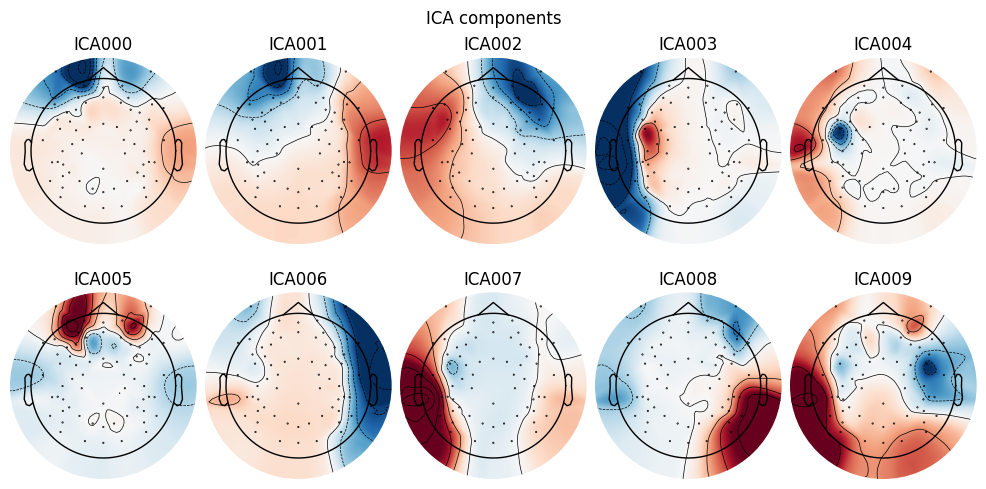

Creating RawArray with float64 data, n_channels=10, n_times=74342
    Range : 0 ... 74341 =      0.000 ...   297.364 secs
Ready.


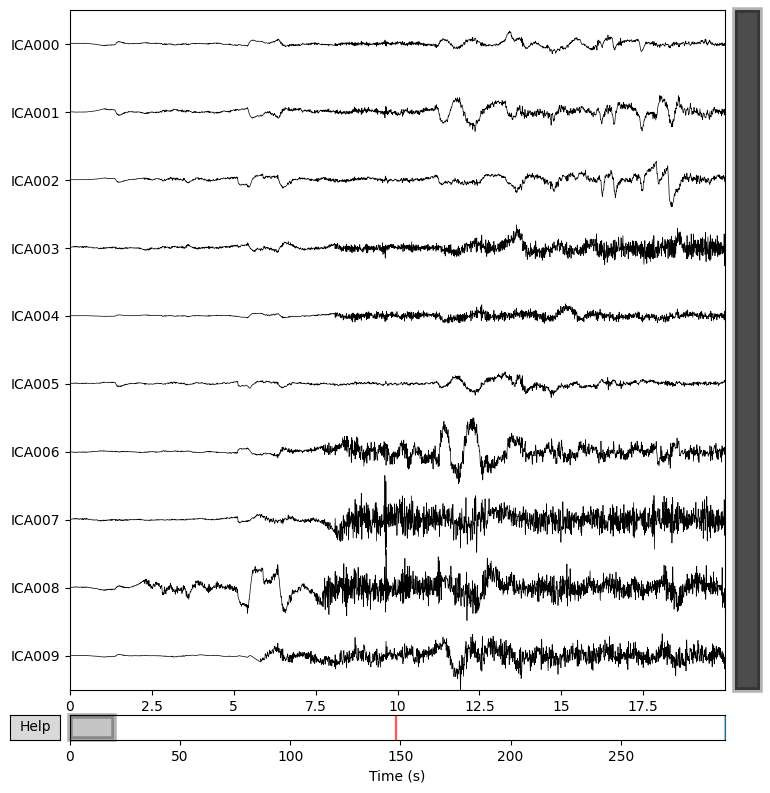


── Listener ICA Components ──


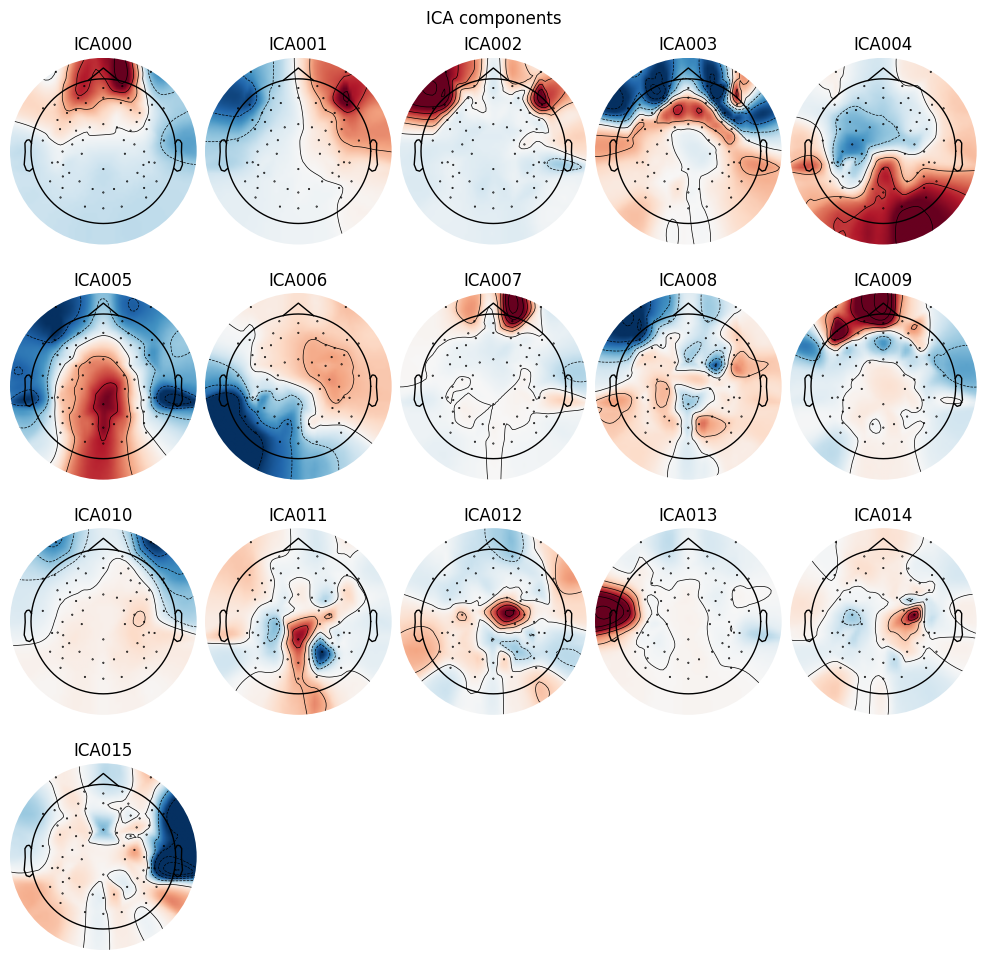

Creating RawArray with float64 data, n_channels=16, n_times=74342
    Range : 0 ... 74341 =      0.000 ...   297.364 secs
Ready.


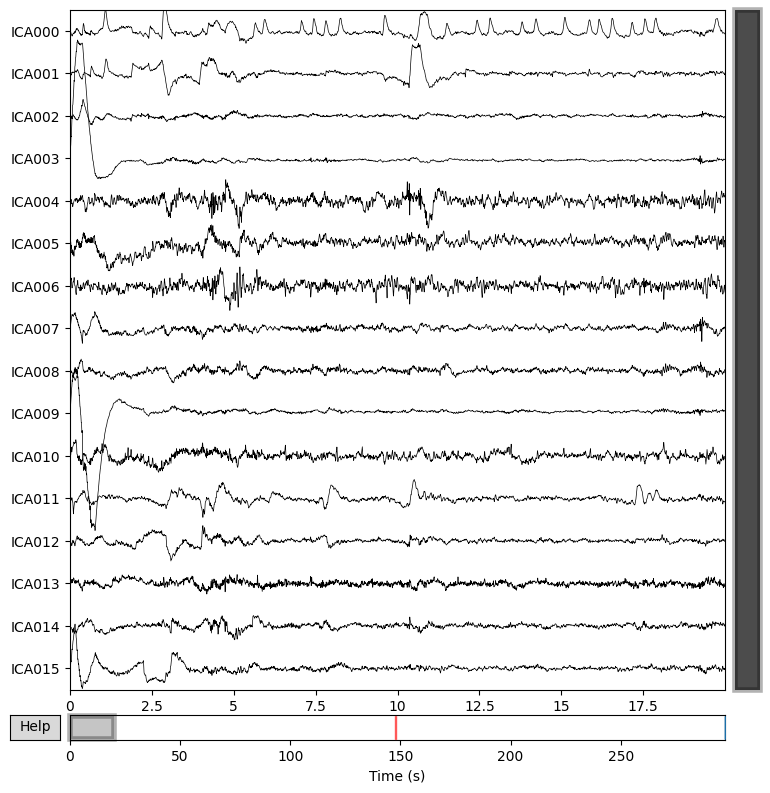

In [54]:
%matplotlib inline
plt.close('all')
# 1. Plot Speaker Components
print("── Speaker ICA Components ──")
ica_speaker.plot_components(inst=sp_filt, show=True);
ica_speaker.plot_sources(sp_filt, show_scrollbars=True, show=True);

# 2. Plot Listener Components
print("\n── Listener ICA Components ──")
ica_listener.plot_components(inst=ls_filt, show=True);
ica_listener.plot_sources(ls_filt, show_scrollbars=True, show=True);

In [55]:
print("── ICA Explained Variance Breakdown ──")

for ica_obj, raw_data, label in [
    (ica_speaker, sp_concat, "Speaker"),
    (ica_listener, ls_concat, "Listener")
]:
    print(f"\n=== {label} ===")
    
    # Ensure data is loaded into memory
    raw_data.load_data()
    
    # 1. Calculate TOTAL explained variance (all components combined)
    total_var_dict = ica_obj.get_explained_variance_ratio(raw_data)
    ch_type = list(total_var_dict.keys())[0]  # Usually 'eeg'
    total_ratio = total_var_dict[ch_type]
    
    # 2. Calculate and print variance for EACH individual component
    print(f"Individual {ch_type.upper()} Variances:")
    for i in range(ica_obj.n_components_):
        # Pass the specific component index 'i' to get its isolated variance
        indiv_var_dict = ica_obj.get_explained_variance_ratio(raw_data, components=i)
        indiv_ratio = indiv_var_dict[ch_type]
        
        print(f"  ICA{i:03d}: {indiv_ratio * 100:5.2f}%")
        
    # 3. Print the grand total at the bottom
    print("-" * 25)
    print(f"TOTAL Explained Variance: {total_ratio * 100:.2f}%\n")

── ICA Explained Variance Breakdown ──

=== Speaker ===
Individual EEG Variances:
  ICA000: 15.37%
  ICA001:  0.31%
  ICA002: -0.19%
  ICA003: 11.61%
  ICA004: -2.98%
  ICA005: -0.19%
  ICA006:  5.97%
  ICA007: 10.06%
  ICA008:  0.46%
  ICA009:  4.20%
-------------------------
TOTAL Explained Variance: 52.01%


=== Listener ===
Individual EEG Variances:
  ICA000: 30.76%
  ICA001:  0.49%
  ICA002:  1.78%
  ICA003: 10.87%
  ICA004:  0.05%
  ICA005: 52.07%
  ICA006: -6.90%
  ICA007: -10.94%
  ICA008:  9.79%
  ICA009: -0.25%
  ICA010:  8.88%
  ICA011: -0.11%
  ICA012:  4.41%
  ICA013: -0.17%
  ICA014: -0.12%
  ICA015:  5.17%
-------------------------
TOTAL Explained Variance: 92.28%



In [56]:
print(f"Speaker  ICA components: {ica_speaker.n_components_}")
print(f"Listener ICA components: {ica_listener.n_components_}")

# Also check how much variance the PCA retained
print(f"Speaker  PCA components: {ica_speaker.pca_components_.shape[0]}")
print(f"Listener PCA components: {ica_listener.pca_components_.shape[0]}")

# And the explained variance ratio
print(f"Speaker  PCA variance explained: "
      f"{ica_speaker.pca_explained_variance_[:ica_speaker.n_components_].sum():.3f}")

Speaker  ICA components: 10
Listener ICA components: 16
Speaker  PCA components: 64
Listener PCA components: 64
Speaker  PCA variance explained: 61.254


In [57]:
output_dir = 'ica_plots'
os.makedirs(output_dir, exist_ok=True)
print(f"Saving all plots to the '{output_dir}' directory. This may take a minute or two...")


fig_sp_psd = sp_concat.compute_psd(fmin=1, fmax=45).plot(show=False)
fig_sp_psd.savefig(os.path.join(output_dir, 'Speaker_00_PSD_Before_ICA.png'), dpi=150)
plt.close(fig_sp_psd)

fig_ls_psd = ls_concat.compute_psd(fmin=1, fmax=45).plot(show=False)
fig_ls_psd.savefig(os.path.join(output_dir, 'Listener_00_PSD_Before_ICA.png'), dpi=150)
plt.close(fig_ls_psd)


print("Generating Speaker ICA Properties...")
sp_figs = ica_speaker.plot_properties(sp_filt, picks=list(range(10)), show=False)
for i, fig in enumerate(sp_figs):
    fig.savefig(os.path.join(output_dir, f'Speaker_ICA_Prop_{i:02d}.png'), dpi=150)
    plt.close(fig) # Keep memory clean

# ── 3. Save ICA Properties for Listener (All 30 Components) ──
print("Generating Listener ICA Properties...")
ls_figs = ica_listener.plot_properties(ls_filt, picks=list(range(15)), show=False)
for i, fig in enumerate(ls_figs):
    fig.savefig(os.path.join(output_dir, f'Listener_ICA_Prop_{i:02d}.png'), dpi=150)
    plt.close(fig) # Keep memory clean

# ── 4. Zip the folder for easy download ──
print("Zipping the images...")
zip_filename = 'ica_plots_complete.zip'
with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for root, dirs, files in os.walk(output_dir):
        for file in files:
            file_path = os.path.join(root, file)
            zipf.write(file_path, arcname=file)

print(f"✓ Success! All 27 plots have been saved and zipped into '{zip_filename}'.")

Saving all plots to the 'ica_plots' directory. This may take a minute or two...
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Generating Speaker ICA Properties...
    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
147 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
147 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
147 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
147 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
147 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
147 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
147 m

In [58]:
!pip install mne-icalabel

In [116]:
from mne_icalabel import label_components

def detect_auto_ica(ica, raw_filt, label=''):
    print(f"\n── {label}: AI Artifact Detection ──")
    
    ic_labels = label_components(raw_filt, ica, method='iclabel')
    
    auto_exclude = []
    labels = ic_labels['labels']
    probs = ic_labels['y_pred_proba']
    
    for i, (pred_label, prob) in enumerate(zip(labels, probs)):
        # THE FIX: Added 'other' and 'channel noise' to the drop list
        if pred_label in ['eye blink', 'muscle artifact', 'other', 'channel noise'] and prob >= 0.70:
            print(f"  [X] AI Flags ICA{i:03d}: {pred_label.upper():<15} (Confidence: {prob:.1%})")
            auto_exclude.append(i)
        elif pred_label == 'brain':
            print(f"  [✓] AI Keeps ICA{i:03d}: {pred_label.upper():<15} (Confidence: {prob:.1%})")
        else:
            print(f"  [✓] AI Keeps ICA{i:03d}: {pred_label:<15} (Confidence: {prob:.1%})")
            
    ica.exclude = auto_exclude
    print(f"  Auto-flagged components to drop: {ica.exclude}")
    return auto_exclude

# Run detection only
sp_auto_exclude = detect_auto_ica(ica_speaker, sp_filt, "Speaker")
ls_auto_exclude = detect_auto_ica(ica_listener, ls_filt, "Listener")


── Speaker: AI Artifact Detection ──
  [X] AI Flags ICA000: EYE BLINK       (Confidence: 96.6%)
  [✓] AI Keeps ICA001: eye blink       (Confidence: 62.2%)
  [X] AI Flags ICA002: EYE BLINK       (Confidence: 77.0%)
  [✓] AI Keeps ICA003: BRAIN           (Confidence: 36.1%)
  [✓] AI Keeps ICA004: other           (Confidence: 63.0%)
  [X] AI Flags ICA005: EYE BLINK       (Confidence: 82.5%)
  [✓] AI Keeps ICA006: BRAIN           (Confidence: 48.7%)
  [✓] AI Keeps ICA007: eye blink       (Confidence: 43.9%)
  [✓] AI Keeps ICA008: BRAIN           (Confidence: 76.9%)
  [✓] AI Keeps ICA009: other           (Confidence: 35.5%)
  Auto-flagged components to drop: [0, 2, 5]

── Listener: AI Artifact Detection ──
  [✓] AI Keeps ICA000: eye blink       (Confidence: 62.9%)
  [X] AI Flags ICA001: EYE BLINK       (Confidence: 99.8%)
  [✓] AI Keeps ICA002: eye blink       (Confidence: 60.0%)
  [✓] AI Keeps ICA003: other           (Confidence: 58.9%)
  [✓] AI Keeps ICA004: BRAIN           (Confidence: 

In [67]:
# ── Correct MNE ICA PCA attribute names ──────────────────────────────────────

print("=== Speaker ICA ===")
print(f"  n_components_ (ICA)          : {ica_speaker.n_components_}")
print(f"  pca_components_ shape        : {ica_speaker.pca_components_.shape}")
print(f"  pca_explained_variance_ shape: {ica_speaker.pca_explained_variance_.shape}")

# pca_explained_variance_ is the raw variance (not ratio) of each PCA component
# To get the ratio, divide by the total
pca_var_sp = ica_speaker.pca_explained_variance_
pca_var_ratio_sp = pca_var_sp / pca_var_sp.sum()

print(f"\n  PCA dims retained            : {len(pca_var_sp)}")
print(f"  Variance in first 10 dims    : {pca_var_ratio_sp[:10].sum()*100:.2f}%")
print(f"  Variance in first 20 dims    : {pca_var_ratio_sp[:20].sum()*100:.2f}%")
print(f"  Variance in all dims         : {pca_var_ratio_sp.sum()*100:.2f}%")

print("\n  Per-component variance ratio (first 15):")
for i, v in enumerate(pca_var_ratio_sp[:15]):
    bar = '█' * int(v * 200)
    print(f"    PCA{i:03d}: {v*100:6.2f}%  {bar}")

print("\n=== Listener ICA ===")
pca_var_ls = ica_listener.pca_explained_variance_
pca_var_ratio_ls = pca_var_ls / pca_var_ls.sum()

print(f"  PCA dims retained            : {len(pca_var_ls)}")
print(f"  Variance in first 16 dims    : {pca_var_ratio_ls[:16].sum()*100:.2f}%")
print(f"  Variance in all dims         : {pca_var_ratio_ls.sum()*100:.2f}%")

print("\n  Per-component variance ratio (first 20):")
for i, v in enumerate(pca_var_ratio_ls[:20]):
    bar = '█' * int(v * 200)
    print(f"    PCA{i:03d}: {v*100:6.2f}%  {bar}")

=== Speaker ICA ===
  n_components_ (ICA)          : 10
  pca_components_ shape        : (64, 64)
  pca_explained_variance_ shape: (64,)

  PCA dims retained            : 64
  Variance in first 10 dims    : 95.71%
  Variance in first 20 dims    : 98.99%
  Variance in all dims         : 100.00%

  Per-component variance ratio (first 15):
    PCA000:  46.95%  █████████████████████████████████████████████████████████████████████████████████████████████
    PCA001:  18.15%  ████████████████████████████████████
    PCA002:  14.91%  █████████████████████████████
    PCA003:   4.89%  █████████
    PCA004:   3.54%  ███████
    PCA005:   1.96%  ███
    PCA006:   1.90%  ███
    PCA007:   1.57%  ███
    PCA008:   0.98%  █
    PCA009:   0.87%  █
    PCA010:   0.69%  █
    PCA011:   0.56%  █
    PCA012:   0.44%  
    PCA013:   0.36%  
    PCA014:   0.29%  

=== Listener ICA ===
  PCA dims retained            : 64
  Variance in first 16 dims    : 95.28%
  Variance in all dims         : 100.00%

  Pe

# How to select for dropping ica 
## 1 - Topography plot - 
###    a) - Eyeblinks - intense red or blue spots at very front of scalp, right over the eyes
###    b) - Muscle Activity - Intense color at temples ,ears, or base of neck.
###   c) - Neural Signal - color gradients centered over actual brain regions not edge

## 2 - Power Spectral Density(PSD)
###    a) - Healthy Brain activity - 1/f curve, with jump around 10hz(alpha waves)
###    b) - Muscle Activity - not 1/f, flat or increase in power at higher freq starting around 20 till 45

## 3 - Epochs Plot
###   a) - Eye Blinks - flat line interrupted by massive, distinct, low-frequency spikes
###   b) - Muscle Noise - The signal will look like dense, high-frequency "fuzz.". Fuzz getting on and off when jaw moves
###   c) - Neural Data - standard, continuous, somewhat chaotic wave patterns without massive, isolated spikes or dense high-frequency fuzz.

### While automatic channel detection exists like the one and we also tested, but the issue was since there was no EOG channels present, proxies were taken, and during speech, not only eye blinks but jaw, cheeks, forehead moves too, muscle movement creates very high amount of muscle electricity, so these proxy channels have all this information too, automated algorithms only find pearson coorelation of these with ica assuming the proxies contains eye blinks, but since there are a lot of noises in it we can miss it or maybe label muscle movement as eye blinks, so we did manual inspection using "ica.plot_properties", to manullay check the topography and PSDs of the ica to remove them  

In [151]:
sp_manual_exclude = [7,9]
ls_manual_exclude = [0,7]

In [152]:
speaker_exclude = sorted(list(set(sp_auto_exclude) | set(sp_manual_exclude)))
listener_exclude = sorted(list(set(ls_auto_exclude) | set(ls_manual_exclude)))

In [153]:
listener_exclude.remove(9)

── Plotting Excluded Component Time-Series ──
Displaying Speaker components...
Creating RawArray with float64 data, n_channels=5, n_times=74342
    Range : 0 ... 74341 =      0.000 ...   297.364 secs
Ready.


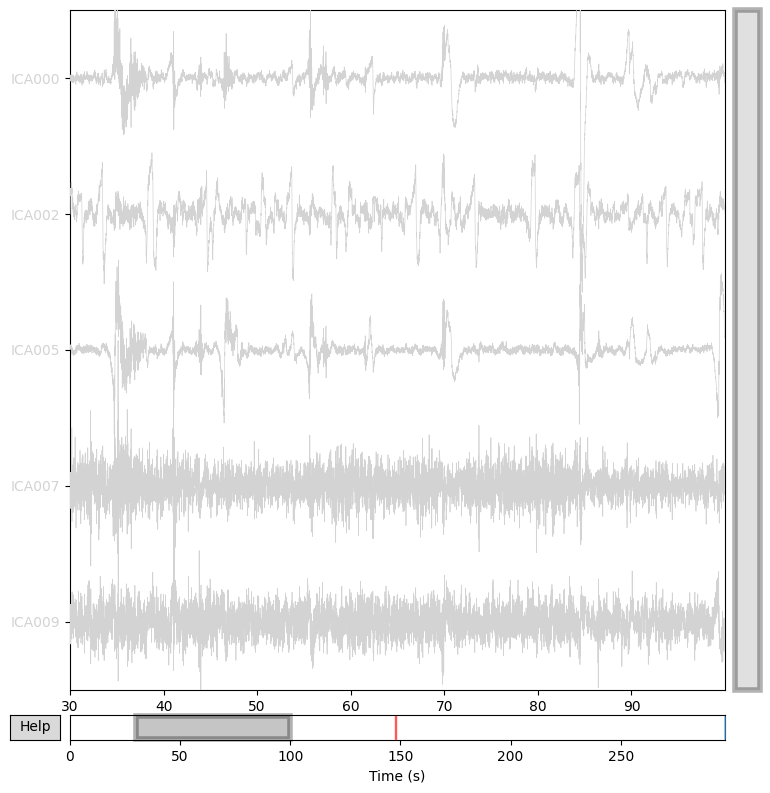

Displaying Listener components...
Creating RawArray with float64 data, n_channels=6, n_times=74342
    Range : 0 ... 74341 =      0.000 ...   297.364 secs
Ready.


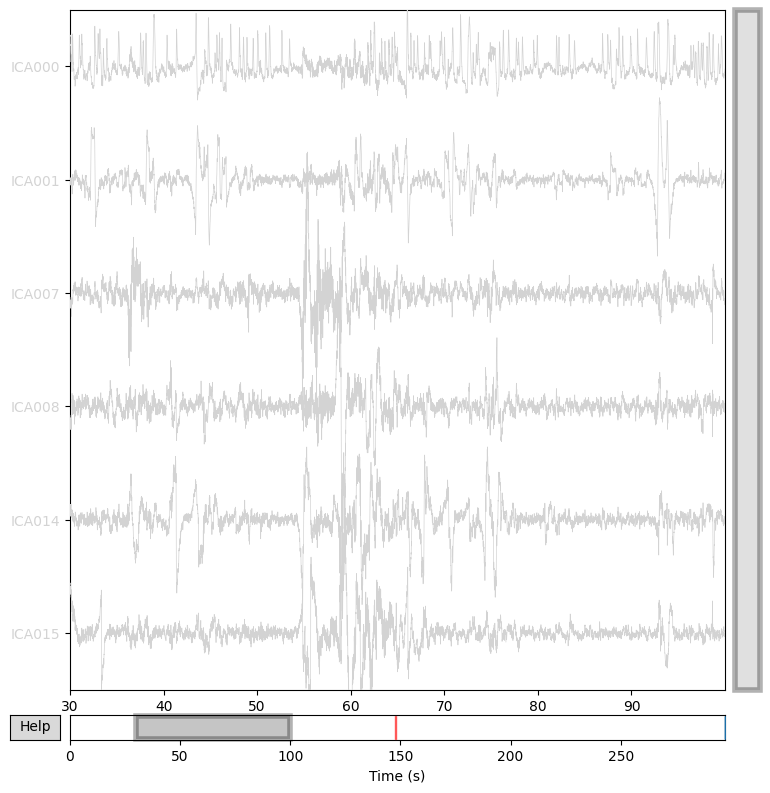

In [154]:
SP_PLOT_COMPONENTS  = speaker_exclude
LS_PLOT_COMPONENTS  = listener_exclude

print("── Plotting Excluded Component Time-Series ──")

for ica, raw_filt, comps, label in [
    (ica_speaker,  sp_filt, SP_PLOT_COMPONENTS, 'Speaker'),
    (ica_listener, ls_filt, LS_PLOT_COMPONENTS, 'Listener')
]:
    if comps:
        print(f"Displaying {label} components...")
        # Changed show=True to display inline instead of saving
        ica.plot_sources(raw_filt, picks=comps, start=30, stop=100,
                         title=f'{label} — Excluded ICA Component Time-Series',
                         show=True)

In [ ]:
ica_speaker.exclude = speaker_exclude
ica_listener.exclude = listener_exclude

print(f'Speaker  — excluding {len(speaker_exclude)} components.')
print(f'Listener — excluding {len(listener_exclude)} components.')

# Apply to the ORIGINAL concatenated data (Not the 1Hz high-pass training copy)
print('\nApplying ICA filters to the main datasets...')
sp_clean = sp_concat.copy()
ls_clean = ls_concat.copy()

ica_speaker.apply(sp_clean)
ica_listener.apply(ls_clean)

print('\n✓ ICA applied — artifact components zeroed out.')
print('  Clean data shapes:')
print(f'    Speaker  : {sp_clean.get_data().shape}')
print(f'    Listener : {ls_clean.get_data().shape}')

In [130]:
pos_duration_sp = sp_positive.times[-1]  
pos_duration_ls = ls_positive.times[-1]

# Speaker Splits
sp_positive_clean = sp_clean.copy().crop(tmin=0, tmax=pos_duration_sp)
sp_negative_clean = sp_clean.copy().crop(tmin=pos_duration_sp)

# Listener Splits
ls_positive_clean = ls_clean.copy().crop(tmin=0, tmax=pos_duration_ls)
ls_negative_clean = ls_clean.copy().crop(tmin=pos_duration_ls)

print("✓ Clean segment durations:")
for lbl, seg in [('sp_positive_clean', sp_positive_clean),
                 ('sp_negative_clean', sp_negative_clean),
                 ('ls_positive_clean', ls_positive_clean),
                 ('ls_negative_clean', ls_negative_clean)]:
    print(f"    {lbl:20s}: {seg.times[-1]:.2f} s")

✓ Clean segment durations:
    sp_positive_clean   : 147.77 s
    sp_negative_clean   : 149.59 s
    ls_positive_clean   : 147.77 s
    ls_negative_clean   : 149.59 s


In [ ]:
%matplotlib inline
plt.close('all')
psd_before = sp_concat.compute_psd(fmin=1, fmax=45)
psd_after = sp_clean.compute_psd(fmin=1, fmax=45)

# 2. Extract frequencies and power arrays
freqs = psd_before.freqs

# MNE's get_data() returns (n_channels, n_freqs). 
# We convert the raw power to decibels (dB) for standard EEG visualization.
power_before_db = 10 * np.log10(psd_before.get_data())
power_after_db = 10 * np.log10(psd_after.get_data())

# 3. Set up a single, large plot
fig, ax = plt.subplots(figsize=(10, 6))

# 4. Plot all channels overlaid
# Transposing (.T) allows matplotlib to plot all 64 channels simultaneously.
# 'Before' is colored red and made highly transparent (alpha=0.2)
ax.plot(freqs, power_before_db.T, color='red', alpha=0.2, linewidth=1)

# 'After' is colored blue and made more opaque so it stands out on top
ax.plot(freqs, power_after_db.T, color='blue', alpha=0.5, linewidth=1)

# 5. Create a clean custom legend (otherwise matplotlib creates 128 labels)
custom_lines = [
    Line2D([0], [0], color='red', alpha=0.5, lw=2),
    Line2D([0], [0], color='blue', alpha=0.8, lw=2)
]
ax.legend(custom_lines, ['Before ICA (Raw)', 'After ICA (Cleaned)'], loc='upper right', fontsize=11)

# 6. Professional Formatting
ax.set_title("Participant A (Speaker): PSD Before & After ICA Artifact Rejection", fontsize=14, fontweight='bold')
ax.set_xlabel("Frequency (Hz)", fontsize=12)
ax.set_ylabel("Power (dB/Hz)", fontsize=12)
ax.set_xlim(1, 45)
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
%matplotlib inline
plt.close('all')
psd_before = ls_concat.compute_psd(fmin=1, fmax=45)
psd_after = ls_clean.compute_psd(fmin=1, fmax=45)

# 2. Extract frequencies and power arrays
freqs = psd_before.freqs

# MNE's get_data() returns (n_channels, n_freqs). 
# We convert the raw power to decibels (dB) for standard EEG visualization.
power_before_db = 10 * np.log10(psd_before.get_data())
power_after_db = 10 * np.log10(psd_after.get_data())

# 3. Set up a single, large plot
fig, ax = plt.subplots(figsize=(10, 6))

# 4. Plot all channels overlaid
# Transposing (.T) allows matplotlib to plot all 64 channels simultaneously.
# 'Before' is colored red and made highly transparent (alpha=0.2)
ax.plot(freqs, power_before_db.T, color='red', alpha=0.2, linewidth=1)

# 'After' is colored blue and made more opaque so it stands out on top
ax.plot(freqs, power_after_db.T, color='blue', alpha=0.5, linewidth=1)

# 5. Create a clean custom legend (otherwise matplotlib creates 128 labels)
custom_lines = [
    Line2D([0], [0], color='red', alpha=0.5, lw=2),
    Line2D([0], [0], color='blue', alpha=0.8, lw=2)
]
ax.legend(custom_lines, ['Before ICA (Raw)', 'After ICA (Cleaned)'], loc='upper right', fontsize=11)

# 6. Professional Formatting
ax.set_title("Participant B (Listener): PSD Before & After ICA Artifact Rejection", fontsize=14, fontweight='bold')
ax.set_xlabel("Frequency (Hz)", fontsize=12)
ax.set_ylabel("Power (dB/Hz)", fontsize=12)
ax.set_xlim(1, 45)
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
os.makedirs('clean_data', exist_ok=True)

# Save the split blocks
sp_positive_clean.save('clean_data/speaker_positive_clean_raw.fif', overwrite=True)
sp_negative_clean.save('clean_data/speaker_negative_clean_raw.fif', overwrite=True)
ls_positive_clean.save('clean_data/listener_positive_clean_raw.fif', overwrite=True)
ls_negative_clean.save('clean_data/listener_negative_clean_raw.fif', overwrite=True)

# Save the full continuous blocks just in case you need them later
sp_clean.save('clean_data/speaker_full_clean_raw.fif', overwrite=True)
ls_clean.save('clean_data/listener_full_clean_raw.fif', overwrite=True)

print("✓ Preprocessing Pipeline 100% Complete! Data is safely stored in the 'clean_data' folder.")